In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Reading

In [9]:
df_online_preproc = pd.read_csv('../data/online_shoppers_preproc.csv')
print(df_online_preproc.shape)
df_online_preproc.head()

(12205, 23)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Region,TrafficType,VisitorType,Weekend,Revenue,total_pages,total_duration,product_related_ratio,avg_time_per_page,is_special_period
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,Region_1,Traffic_1,Returning_Visitor,0,0,1,0.000000,1.0,0.000000,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,Region_1,Traffic_2,Returning_Visitor,0,0,2,64.000000,1.0,32.000000,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,Region_9,Traffic_3,Returning_Visitor,0,0,1,0.000000,1.0,0.000000,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,Region_2,Traffic_4,Returning_Visitor,0,0,2,2.666667,1.0,1.333333,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,Region_1,Traffic_4,Returning_Visitor,1,0,10,627.500000,1.0,62.750000,0


## Feature Selector

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

In [11]:
X = df_online_preproc.drop(columns='Revenue')
y = df_online_preproc['Revenue']

X.shape, y.shape

((12205, 22), (12205,))

In [12]:
# Detectar categóricas
cat_cols = X.select_dtypes(include='object').columns.tolist()

# Convertir a category
for col in cat_cols:
    X[col] = X[col].astype('category')

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Modelo
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

# Entrenamiento
model.fit(
    X_train,
    y_train,
    categorical_feature=cat_cols
)

[LightGBM] [Info] Number of positive: 1526, number of negative: 8238
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000850 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2908
[LightGBM] [Info] Number of data points in the train set: 9764, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.156288 -> initscore=-1.686108
[LightGBM] [Info] Start training from score -1.686108


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [16]:
# =========================
# Predicciones TRAIN
# =========================
y_train_pred = model.predict(X_train)

print('===== TRAIN =====')
print(
    classification_report(
        y_train,
        y_train_pred
    )
)

# =========================
# Predicciones TEST
# =========================
y_test_pred = model.predict(X_test)

print('===== TEST =====')
print(
    classification_report(
        y_test,
        y_test_pred
    )
)

===== TRAIN =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8238
           1       0.97      0.92      0.94      1526

    accuracy                           0.98      9764
   macro avg       0.98      0.96      0.97      9764
weighted avg       0.98      0.98      0.98      9764

===== TEST =====
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2059
           1       0.70      0.60      0.65       382

    accuracy                           0.90      2441
   macro avg       0.82      0.78      0.80      2441
weighted avg       0.89      0.90      0.90      2441



## Permutation Importanc

In [13]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

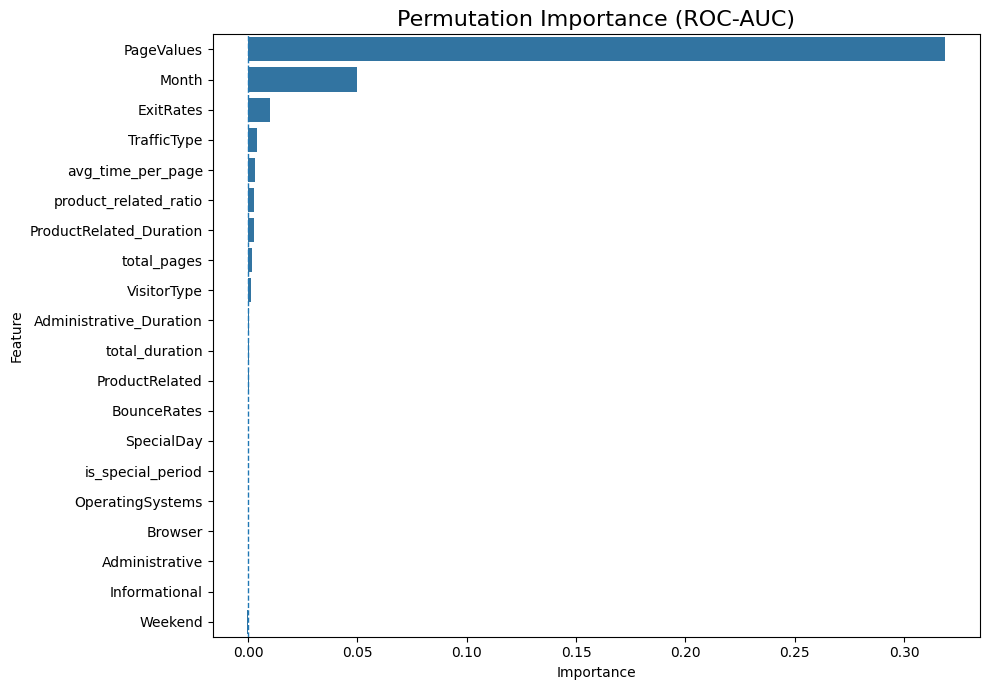

In [14]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': perm.importances_mean
}).sort_values(
    'importance',
    ascending=False
)

top_n = 20
df_plot = importance_df.head(top_n)

# Plot
plt.figure(figsize=(10, 7))

sns.barplot(
    data=df_plot,
    x='importance',
    y='feature'
)

plt.axvline(
    x=0,
    linestyle='--',
    linewidth=1
)

plt.title(
    'Permutation Importance (ROC-AUC)',
    fontsize=16
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()